# Capstone Project: Property Price Prediction

## **Objective**:
Develop a machine learning model that accurately predicts house prices based on various features such as location, property size, construction status, and more. This model will help potential buyers and real estate agents estimate property values, aiding in better decision-making and price forecasting.


### Data Dictionary

| Column Name | Description | Data Type |
| :--- | :--- | :--- |
| POSTED_BY | Person posting the listing (Owner, Dealer, etc.). | Categorical |
| UNDER_CONSTRUCTION | Indicates if the property is under construction (1: Yes, 0: No). | Binary (0/1) |
| RERA | Indicates RERA approval status (1: Approved, 0: Not Approved). | Binary (0/1) |
| BHK_NO. | Number of Bedrooms, Hall, and Kitchen (BHK). | Integer (Discrete) |
| BHK_OR_RK | Property type (BHK or RK – Room Kitchen). | Categorical |
| SQUARE_FT | Total area of the property in square feet. | Float (Continuous) |
| READY_TO_MOVE | Indicates if the property is ready for occupancy (1: Yes, 0: No). | Binary (0/1) |
| RESALE | Indicates if the property is for resale (1: Yes, 0: No). | Binary (0/1) |
| ADDRESS | Location of the property (City, Region). | Text (Alphanumeric) |
| LONGITUDE | Longitude coordinate of the property. | Float (Geographic) |
| LATITUDE | Latitude coordinate of the property. | Float (Geographic) |
| TARGET(PRICE_IN_LACS) | House price in lakhs (Target variable for prediction). | Float (Continuous) |


In [5]:
# !uv pip install pandas matplotlib seaborn plotly scikit-learn scipy statsmodels xgboost lightgbm catboost


## Tasks:
### 1. Import and Load the Data
- Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, xgboost, lightgbm, catboost, scipy, statsmodels, plotly, etc.)
- Load the dataset and explore the structure using .head(), .info() and .describe()


In [6]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


In [19]:
# Load the dataset 'House Price.csv'
property_df = pd.read_csv('House Price.csv')


In [20]:
# Display the shape and structure of the dataset
print("Information about the dataset:", property_df.info())
print("Shape of the dataset:", property_df.shape)
print("\nData types of the columns:\n", property_df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  str    
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  str    
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  str    
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), str(3)
memory usage: 3.5 MB
Information about the dataset: None
Shape of the dataset: (29451, 12)

Data types of the columns:
 POSTED_BY        

In [21]:
print("\nFirst 5 rows of the dataset:\n", property_df.head())



First 5 rows of the dataset:
   POSTED_BY  UNDER_CONSTRUCTION  RERA  BHK_NO. BHK_OR_RK    SQUARE_FT  \
0     Owner                   0     0        2       BHK  1300.236407   
1    Dealer                   0     0        2       BHK  1275.000000   
2     Owner                   0     0        2       BHK   933.159722   
3     Owner                   0     1        2       BHK   929.921143   
4    Dealer                   1     0        2       BHK   999.009247   

   READY_TO_MOVE  RESALE                      ADDRESS  LONGITUDE   LATITUDE  \
0              1       1        Ksfc Layout,Bangalore  12.969910  77.597960   
1              1       1    Vishweshwara Nagar,Mysore  12.274538  76.644605   
2              1       1             Jigani,Bangalore  12.778033  77.632191   
3              1       1  Sector-1 Vaishali,Ghaziabad  28.642300  77.344500   
4              0       1             New Town,Kolkata  22.592200  88.484911   

   TARGET(PRICE_IN_LACS)  
0                   55.0  
1

In [22]:
# Structural and statistical analysis of the dataset
print("\nSummary statistics of the dataset:\n", property_df.describe())



Summary statistics of the dataset:
        UNDER_CONSTRUCTION          RERA       BHK_NO.     SQUARE_FT  \
count        29451.000000  29451.000000  29451.000000  2.945100e+04   
mean             0.179756      0.317918      2.392279  1.980217e+04   
std              0.383991      0.465675      0.879091  1.901335e+06   
min              0.000000      0.000000      1.000000  3.000000e+00   
25%              0.000000      0.000000      2.000000  9.000211e+02   
50%              0.000000      0.000000      2.000000  1.175057e+03   
75%              0.000000      1.000000      3.000000  1.550688e+03   
max              1.000000      1.000000     20.000000  2.545455e+08   

       READY_TO_MOVE        RESALE     LONGITUDE      LATITUDE  \
count   29451.000000  29451.000000  29451.000000  29451.000000   
mean        0.820244      0.929578     21.300255     76.837695   
std         0.383991      0.255861      6.205306     10.557747   
min         0.000000      0.000000    -37.713008   -121.761

In [ ]:
# standardize the names of each column in the dataframe
# remove leading and trailing spaces from each column name
# replace spaces with underscores
updated_column_dict = {}
for col in property_df.columns:
    updated_col_name = col.strip().replace(' ', '_').lower()
    updated_column_dict[col] = updated_col_name

print(updated_column_dict)
property_df = property_df.rename(columns=updated_column_dict)

# Clean the column names to remove special characters
new_col_name_map = {'bhk_no.': 'bhk_no', 'target(price_in_lacs)': 'target_price_in_lacs'}
property_df.rename(columns=new_col_name_map, inplace=True)

print('Information of the dataset after renaming:', property_df.info())


{'posted_by': 'posted_by', 'under_construction': 'under_construction', 'rera': 'rera', 'bhk_no': 'bhk_no', 'bhk_or_rk': 'bhk_or_rk', 'square_ft': 'square_ft', 'ready_to_move': 'ready_to_move', 'resale': 'resale', 'address': 'address', 'longitude': 'longitude', 'latitude': 'latitude', 'target_price_in_lacs': 'target_price_in_lacs'}
<class 'pandas.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   posted_by             29451 non-null  str    
 1   under_construction    29451 non-null  int64  
 2   rera                  29451 non-null  int64  
 3   bhk_no                29451 non-null  int64  
 4   bhk_or_rk             29451 non-null  str    
 5   square_ft             29451 non-null  float64
 6   ready_to_move         29451 non-null  int64  
 7   resale                29451 non-null  int64  
 8   address               29451 non-null  str    
 9   lon

In [27]:
# check duplicates 
dupes_count = property_df.duplicated().sum()

print("Number of duplicate rows:", dupes_count)
if dupes_count > 0:
    # remove duplicates
    property_df.drop_duplicates(inplace=True)
    print("Number of duplicate rows after removing duplicates:", property_df.duplicated().sum())


Number of duplicate rows: 0


### 2. Exploratory Data Analysis (EDA)
- Visualize the distribution of each feature
- Understand correlations (especially with the target variable)
- Check for variables distributions.
- Summarize insights from EDA


#### a. Visualize the distribution of each feature


In [29]:
num_cols = property_df.select_dtypes(['int64', 'float64']).columns
cat_cols = property_df.select_dtypes(['str']).columns

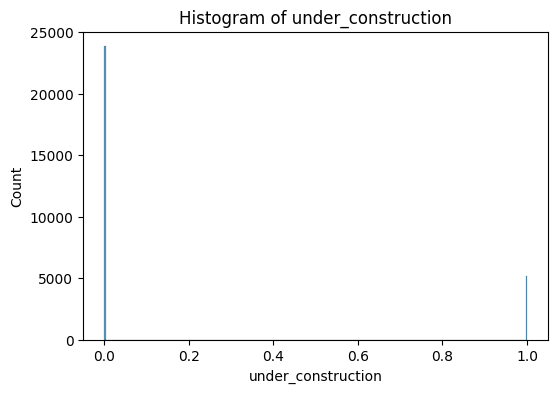

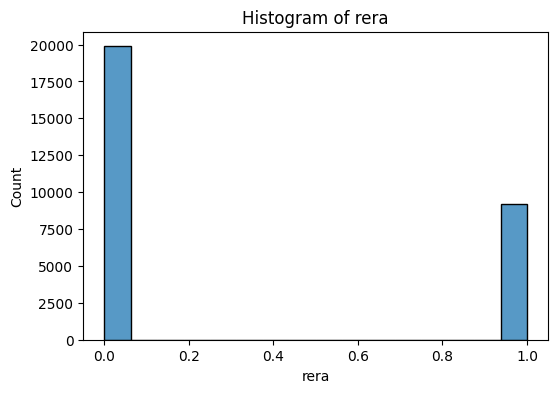

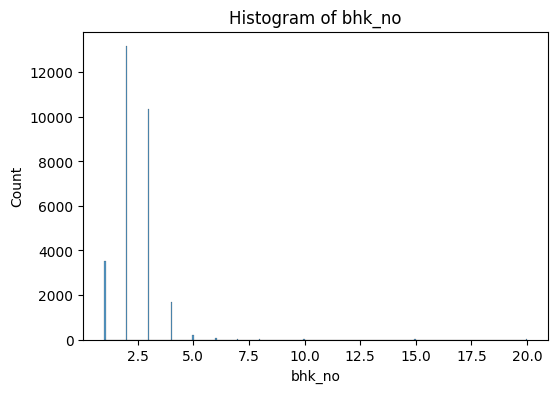

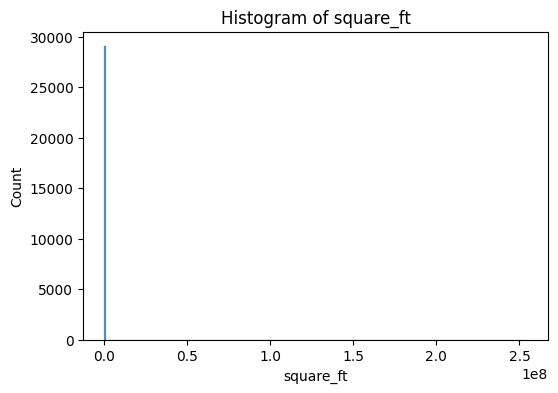

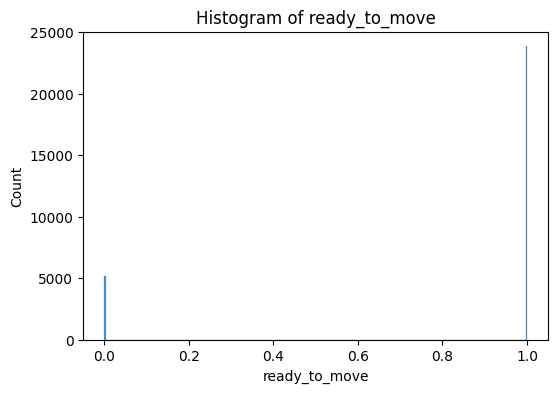

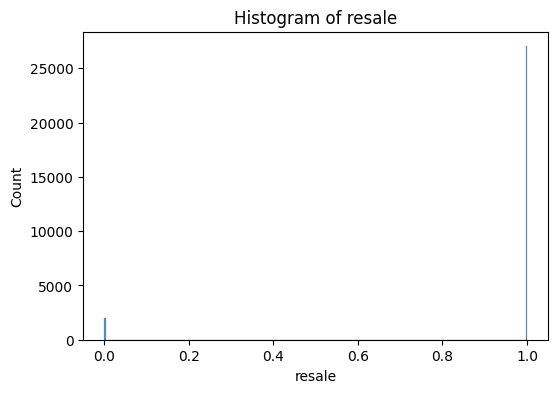

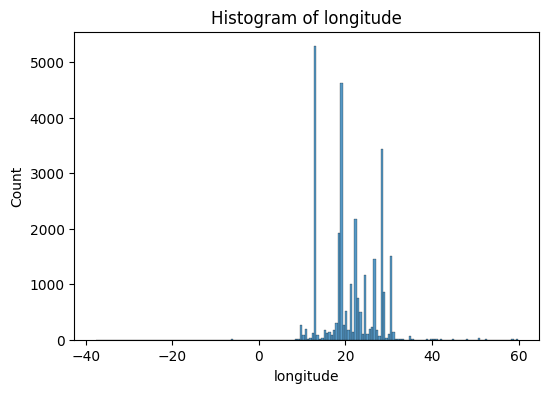

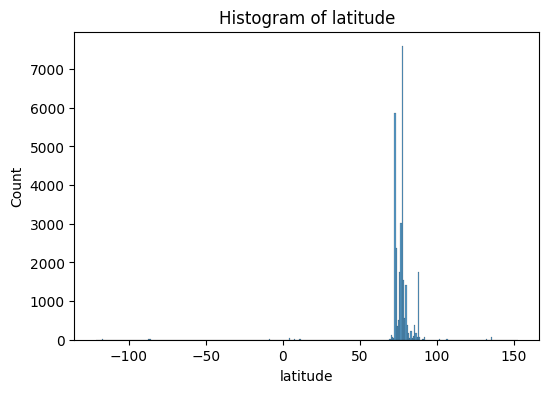

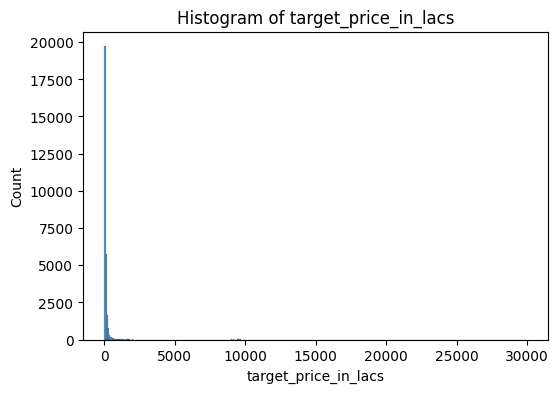

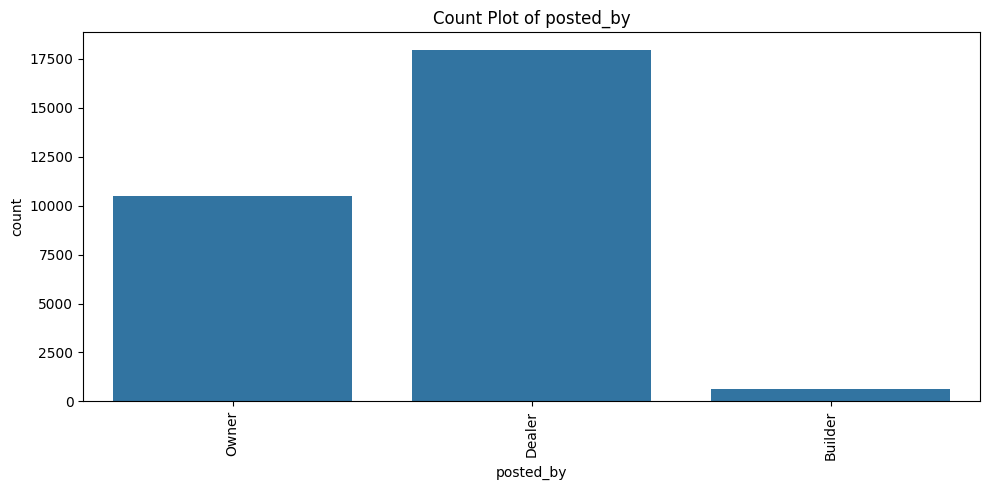

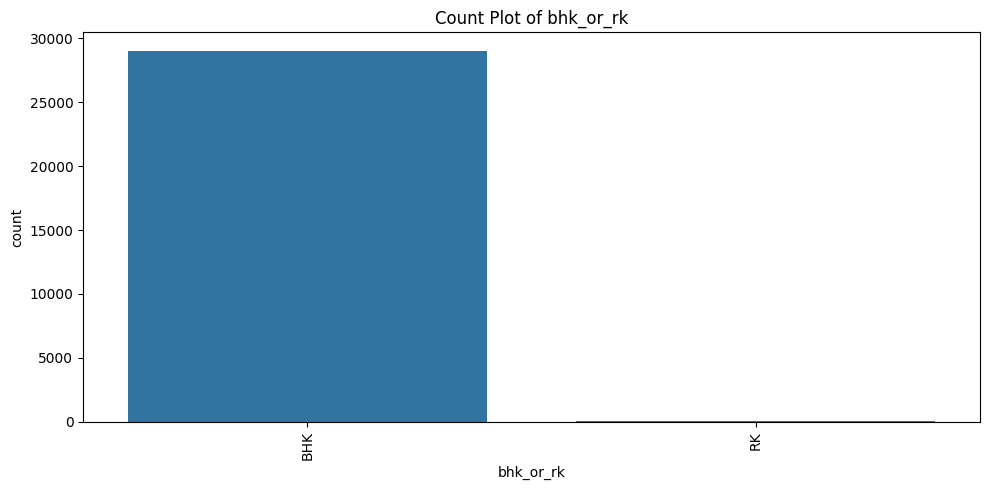

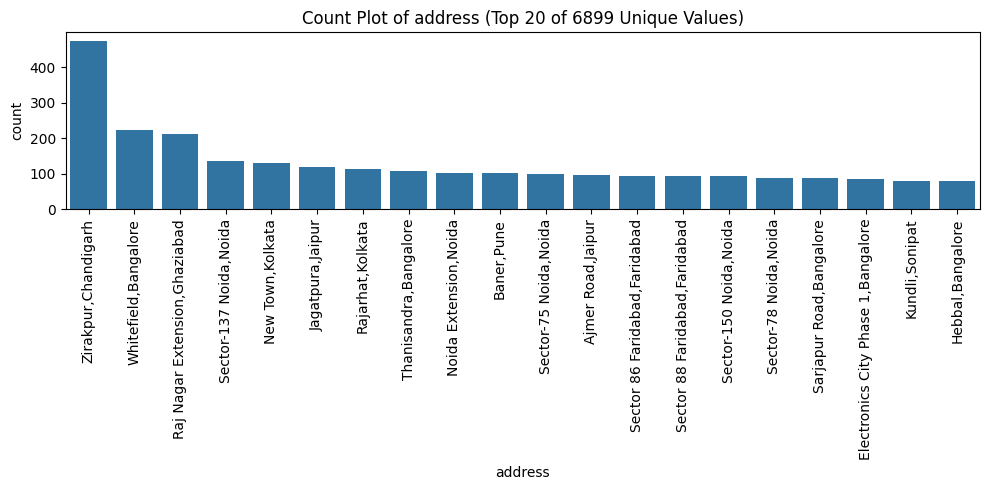

In [ ]:
# Visualize the distribution of each feature
# TODO: Use seaborn's histplot or matplotlib for numeric features, and countplot/barplots for categorical features

# numeric columns distribution
for column in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(x=property_df[column])
    plt.title(f'Histogram of {column}')
    plt.show()

# category columns distribution
for column in cat_cols:
    num_unique = property_df[column].nunique()
    
    # Increase figure width to accommodate text better
    plt.figure(figsize=(10, 5)) 
    
    if num_unique > 20:
        # If there are too many categories, plot only the top 20 most frequent ones
        # For the address column, this is the case
        top_20_categories = property_df[column].value_counts().iloc[:20].index
        sns.countplot(x=property_df[column], order=top_20_categories)
        plt.title(f'Count Plot of {column} (Top 20 of {num_unique} Unique Values)')
    else:
        # Plot normally if categories are 20 or fewer
        sns.countplot(x=property_df[column])
        plt.title(f'Count Plot of {column}')
        
    # Rotate labels by 90 degrees to fit long text like addresses
    plt.xticks(rotation=90)
    
    # tight_layout() ensures the labels don't get cut off at the bottom of the image
    plt.tight_layout() 
    plt.show()



#### b. Understand correlations (especially with the target variable)


In [ ]:
# Find correlation matrix
# TODO: Encode categorical variables first if necessary, then calculate and visualize the correlation matrix using sns.heatmap


In [ ]:
# Calculate the correlation of each feature with the target variable 'target(price_in_lacs)'
# TODO: Sort and visualize the correlations with the target variable


#### c. Check for variables distributions. 


In [ ]:
# Analyze distributions
# TODO: Further inspect histograms, identify skewed variables, and possibly use plotly for interactive visualizations if helpful


#### d. Summarize insights from EDA

*TODO: Write insights gathered from the EDA steps above. Mention highly correlated features, skewness, and patterns observed.*


### 3. Missing Values & Outlier Treatment
- a. Check for missing values and treat them if any
- b. Check if there are any outliers.


#### a. Check for missing values and treat them if any


In [ ]:
# Analyze for missing values in the dataset
# TODO: Use .isnull().sum() and handle any missing data appropriately (e.g., imputation or removal)


#### b. Check if there are any outliers.


In [ ]:
# Check for outliers using boxplots
# TODO: Use sns.boxplot for numerical features to visualize outliers


In [ ]:
# Treat outliers
# TODO: Decide whether to remove or cap outliers (e.g., using quantiles or IQR methods) and implement the treatment


### 4. Feature Engineering & Preprocessing
- a. Encode categorical variables
- b. Feature scaling for numerical values
- c. Check for skewness and treat it if required.


#### a. Encode categorical variables


In [ ]:
# Encode categorical variables (e.g., posted_by, bhk_or_rk, address, etc.)
# TODO: Use pd.get_dummies, LabelEncoder, or TargetEncoder based on the feature properties


#### b. Feature scaling for numerical values


In [ ]:
# Feature scaling for numerical values
# TODO: Use StandardScaler or MinMaxScaler on numerical columns (excluding the target variable if not needed)


#### c. Check for skewness and treat it if required.


In [ ]:
# Check for skewness and kurtosis
# TODO: Analyze skewness/kurtosis of numerical variables and apply transformations (e.g., log, Box-Cox) where necessary


### 5. Model Building: Try Multiple Regressors
Use regression-based models to train and test the data:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- SVR
- KNN
- Ensemble Learning methods (XGBoost, LightGBM, CatBoost)


In [ ]:
# Prepare the train and test data
# TODO: Separate features (X) and target variable (y). Then split into train and test sets using train_test_split


In [ ]:
# Initialize and train multiple regressors
# TODO: Fit Linear Regression, Decision Tree, Random Forest, SVR, KNN


In [ ]:
# Initialize and train Gradient Boosting models
# TODO: Fit XGBoost, LightGBM, CatBoost, and GradientBoostingRegressor


### 6. Model Evaluation & Overfitting Check
- Use metrics:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Root Mean Squared Error (RMSE)
    - R² Score
    - Adjusted R² Score
- Compare performance on both datasets (Training and testing) to detect overfitting


In [ ]:
# Define a function to train, evaluate and collect metrics for each model
# TODO: Calculate MAE, MSE, RMSE, R2, and Adjusted R2 for both train and test predictions


In [ ]:
# Compare performance
# TODO: Store results in a DataFrame and print it out to determine the best model and check for overfitting gaps
